In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../fraudTrain.csv')

In [3]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
df.drop(df.columns[0], axis=1, inplace=True)

In [6]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
985152,2020-02-05 04:40:28,4423489490781412,"fraud_Zboncak, Rowe and Murazik",shopping_net,3.08,Christopher,Ortega,M,5045 Emily Wall,Princeton,IA,52768,41.6858,-90.3706,1426,Agricultural consultant,1957-03-06,1a53991b860cd188cfc9efa8bb12c1a6,1360039228,41.524567,-90.816314,0


In [7]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


### Category Column

In [8]:
import pandas as pd

total_counts_by_category = df['category'].value_counts()

fraud_counts_by_category = df.groupby('category')['is_fraud'].sum()

# Step 3: Calculate non-fraudulent transactions
non_fraud_counts_by_category = total_counts_by_category - fraud_counts_by_category

fraud_ratio_by_category = fraud_counts_by_category / total_counts_by_category

# Step 5: Combine the results into a single DataFrame
combined_counts = pd.DataFrame({
    'total_tran': total_counts_by_category,
    'total_frauds': fraud_counts_by_category,
    'fraud_ratio': fraud_ratio_by_category,
    'total_non_frauds': non_fraud_counts_by_category,

}).fillna(0)  # Fill NaN with 0 for categories with no frauds

combined_counts_category_sorted = combined_counts.sort_values(by='total_frauds', ascending=False)

print(combined_counts_category_sorted)


                total_tran  total_frauds  fraud_ratio  total_non_frauds
category                                                               
grocery_pos         123638          1743     0.014098            121895
shopping_net         97543          1713     0.017561             95830
misc_net             63287           915     0.014458             62372
shopping_pos        116672           843     0.007225            115829
gas_transport       131659           618     0.004694            131041
misc_pos             79655           250     0.003139             79405
kids_pets           113035           239     0.002114            112796
entertainment        94014           233     0.002478             93781
personal_care        90758           220     0.002424             90538
home                123115           198     0.001608            122917
food_dining          91461           151     0.001651             91310
grocery_net          45452           134     0.002948           

/var/folders/tt/ndzk13v944z9y5c79vdqq_mr0000gp/T/ipykernel_49559/3902720609.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(combined_counts_category_sorted.index, rotation=90)


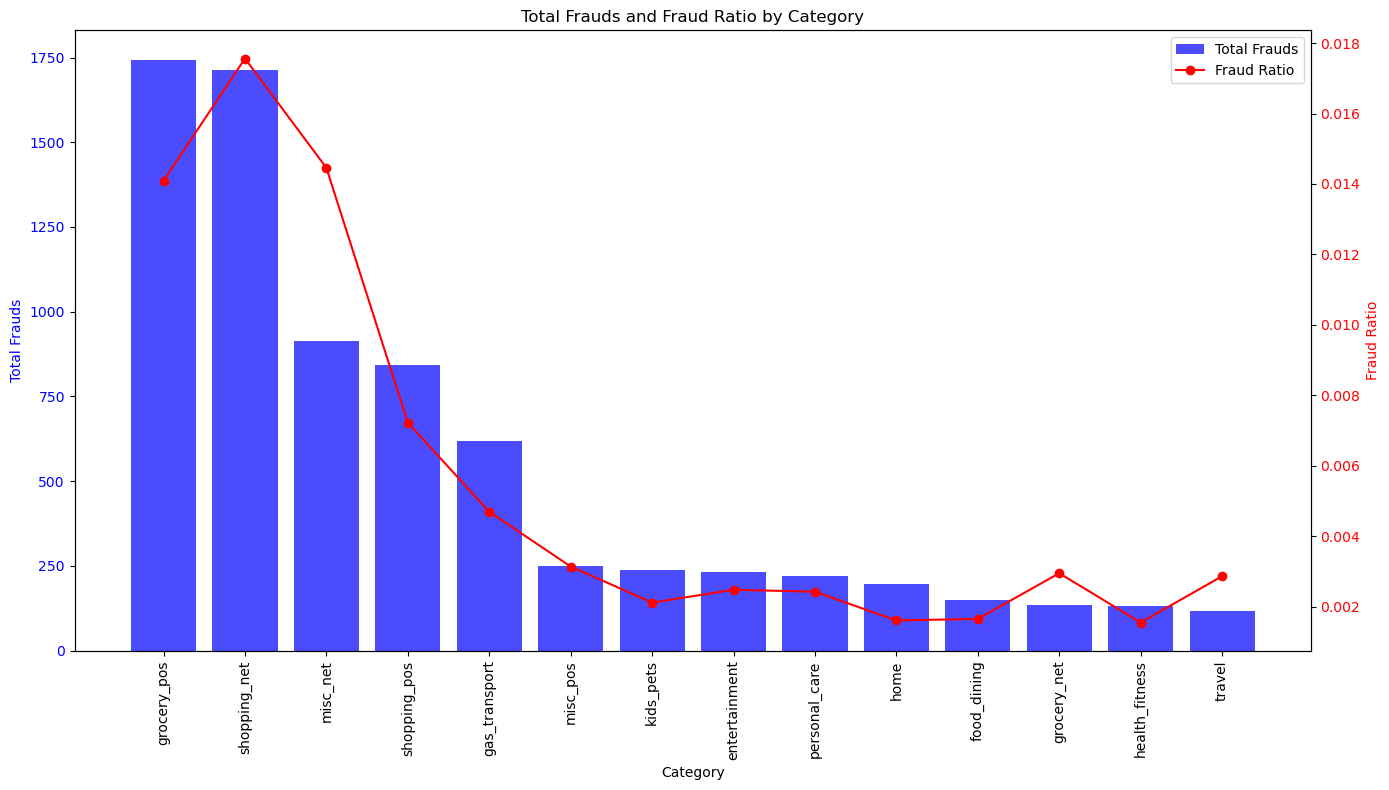

In [9]:
# Plotting the bar graph
fig, ax1 = plt.subplots(figsize=(14, 8))

ax1.bar(combined_counts_category_sorted.index, combined_counts_category_sorted['total_frauds'], color='b', alpha=0.7, label='Total Frauds')
ax1.set_xlabel('Category')
ax1.set_ylabel('Total Frauds', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticklabels(combined_counts_category_sorted.index, rotation=90)

# Create a secondary y-axis for the fraud ratio
ax2 = ax1.twinx()
ax2.plot(combined_counts_category_sorted.index, combined_counts_category_sorted['fraud_ratio'], color='r', marker='o', label='Fraud Ratio')
ax2.set_ylabel('Fraud Ratio', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and legend
plt.title('Total Frauds and Fraud Ratio by Category')
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Show the plot
plt.show()

In [10]:
duplicates = df[df.duplicated()]
duplicates

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


In [11]:
df.dtypes

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

## Data and Time Series

In [12]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [13]:
df['dob'] = pd.to_datetime(df['dob'])

In [14]:
df['dob'].isna().sum()

0

In [15]:
df['year'] = df['trans_date_trans_time'].dt.year
df['month'] = df['trans_date_trans_time'].dt.month
df['day'] = df['trans_date_trans_time'].dt.day
df['time'] = df['trans_date_trans_time'].dt.time

In [16]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
335709,2019-06-08 16:20:34,4474324669797121,fraud_Ruecker-Mayert,kids_pets,24.01,Matthew,Russell,M,168 Michael Coves Suite 343,June Lake,CA,93529,37.7773,-119.0825,633,Health service manager,1927-09-09,b3eb14b7ca54981df984bf59794a852c,1339172434,38.555736,-119.906295,0,2019,6,8,16:20:34


In [17]:
df['month'].value_counts()

month
5     146875
6     143811
3     143789
12    141060
4     134970
1     104727
2      97657
8      87359
7      86596
9      70652
11     70421
10     68758
Name: count, dtype: int64

In [18]:
df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')

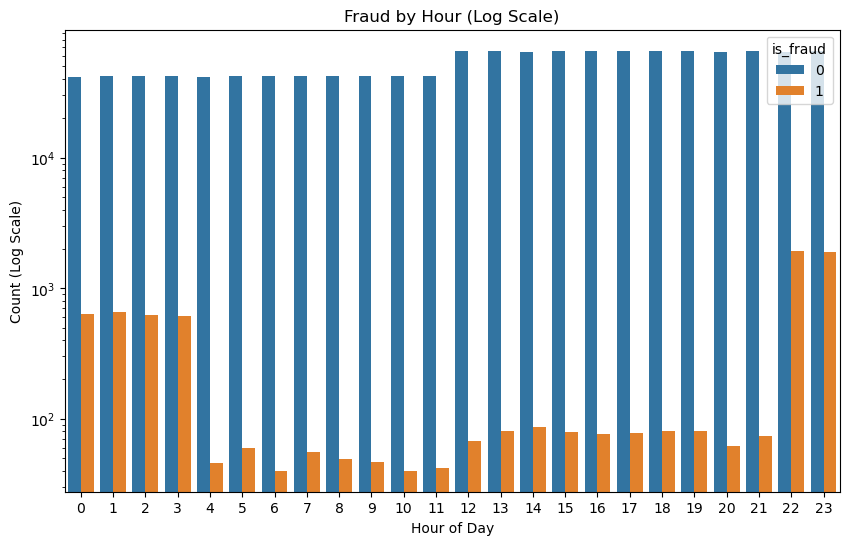

In [19]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=df['time'].dt.hour, hue=df['is_fraud'])
ax.set_yscale('log')
plt.title('Fraud by Hour (Log Scale)')
plt.xlabel('Hour of Day')
plt.ylabel('Count (Log Scale)')
plt.show()

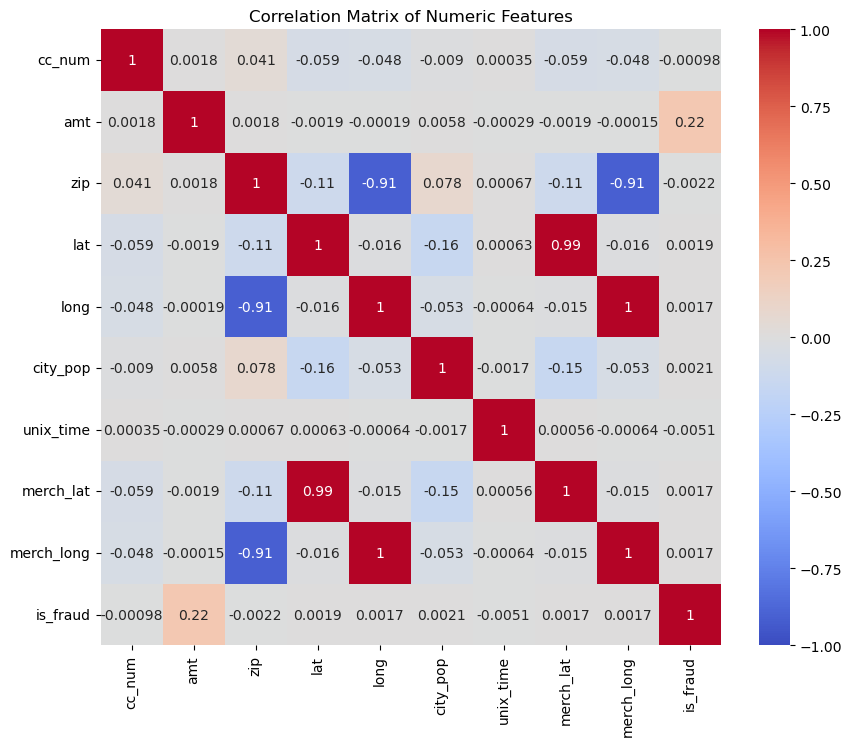

In [20]:
# Select only numeric columns (float and int)
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
correlation_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Tried to plot the number of fraud using lat and long

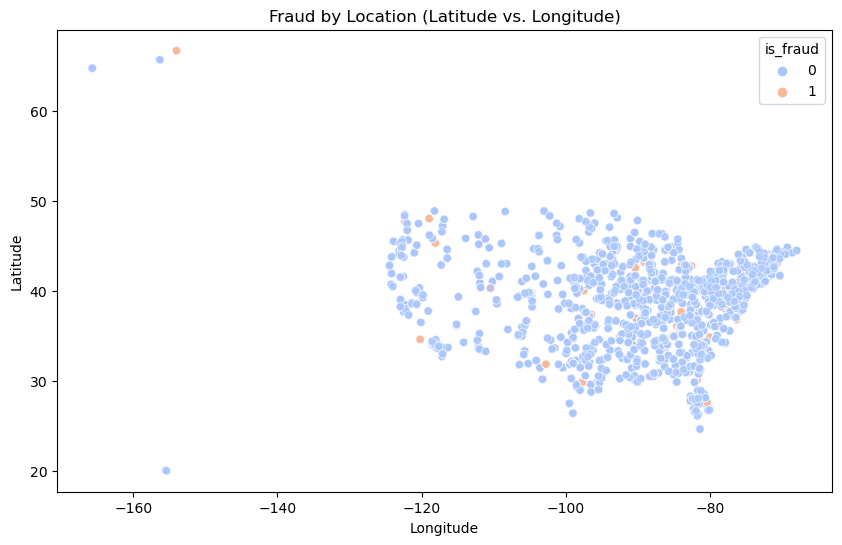

In [21]:
import geopandas as gpd
import contextily as ctx


# Scatter plot of latitude and longitude to visualize fraud occurrences
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='long', y='lat', hue='is_fraud', palette='coolwarm', alpha=0.7)
plt.title('Fraud by Location (Latitude vs. Longitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


### Looking at the City Polulation in relation to Amount and Fraud

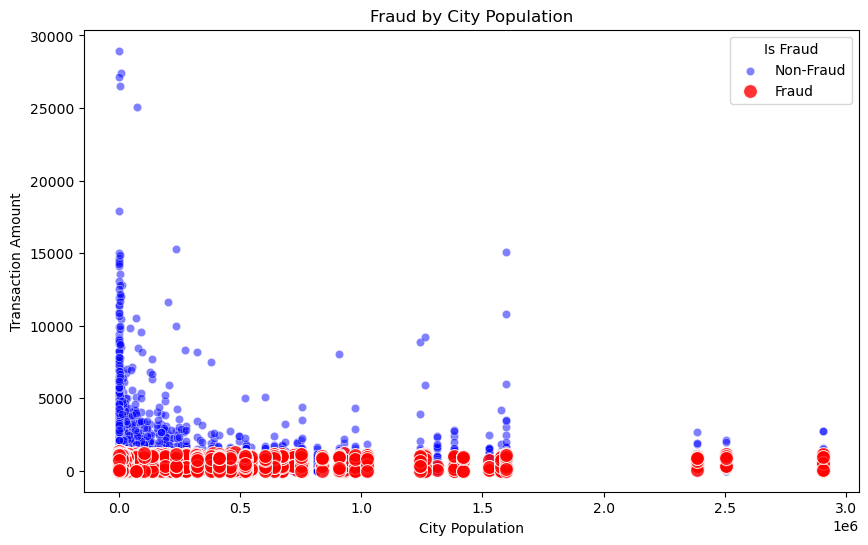

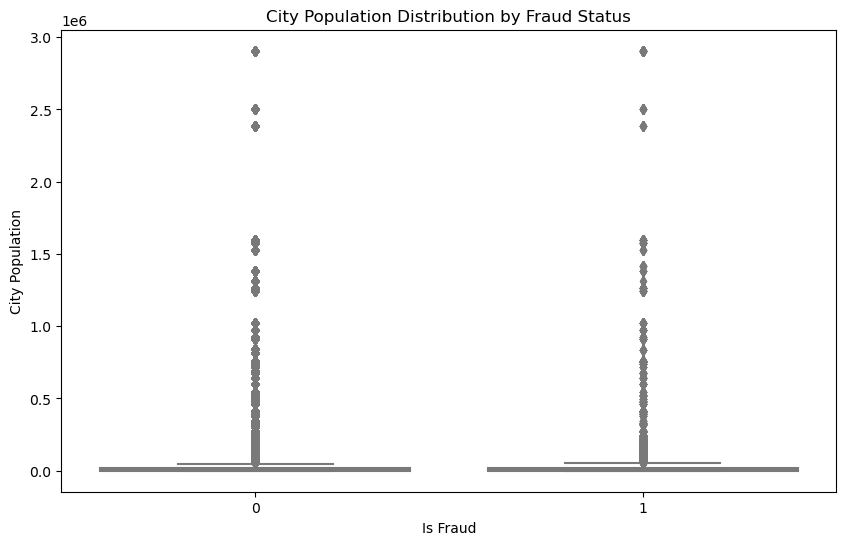

In [22]:
# Separate the data into fraudulent and non-fraudulent transactions
df_fraud = df[df['is_fraud'] == 1]
df_non_fraud = df[df['is_fraud'] == 0]

# Scatter plot of city population to visualize fraud occurrences
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_non_fraud, x='city_pop', y='amt', color='blue', alpha=0.5, label='Non-Fraud')
sns.scatterplot(data=df_fraud, x='city_pop', y='amt', color='red', s=100, alpha=0.8, label='Fraud')
plt.title('Fraud by City Population')
plt.xlabel('City Population')
plt.ylabel('Transaction Amount')
plt.legend(title='Is Fraud', loc='upper right')
plt.show()

# Box plot of city population for fraudulent and non-fraudulent transactions
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_fraud', y='city_pop', palette='coolwarm')
plt.title('City Population Distribution by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('City Population')
plt.show()

### Looked into the amount

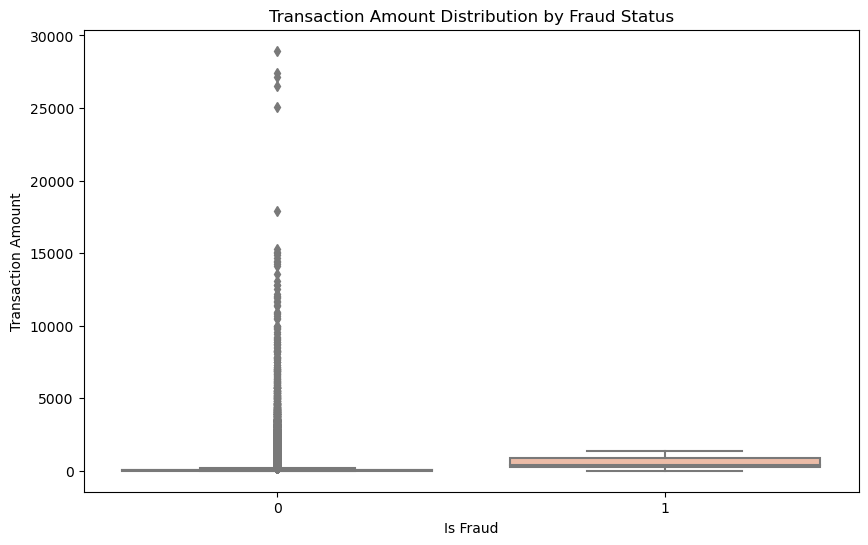

In [23]:
# Box plot of transaction amount
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_fraud', y='amt', palette='coolwarm')
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')
plt.show()



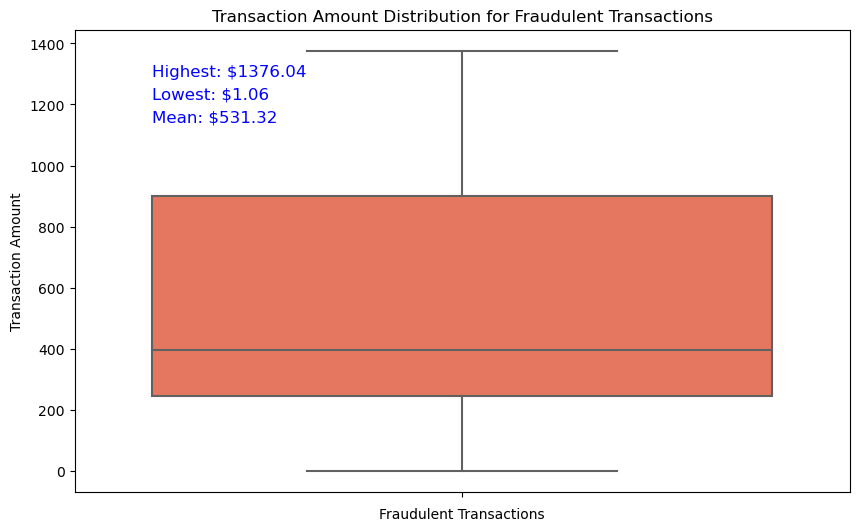

In [24]:

df_fraud = df[df['is_fraud'] == 1]

highest_amt = df_fraud['amt'].max()
lowest_amt = df_fraud['amt'].min()
mean_amt = df_fraud['amt'].mean()
# Box plot of transaction amount for fraudulent transactions
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fraud, y='amt', palette='Reds')
plt.title('Transaction Amount Distribution for Fraudulent Transactions')
plt.xlabel('Fraudulent Transactions')
plt.ylabel('Transaction Amount')

plt.text(0.1, 0.9, f'Highest: ${highest_amt:.2f}', transform=plt.gca().transAxes, fontsize=12, color='blue')
plt.text(0.1, 0.85, f'Lowest: ${lowest_amt:.2f}', transform=plt.gca().transAxes, fontsize=12, color='blue')
plt.text(0.1, 0.8, f'Mean: ${mean_amt:.2f}', transform=plt.gca().transAxes, fontsize=12, color='blue')

plt.show()

In [25]:
count_df_scs = df.groupby(['street', 'city', 'state']).size().reset_index(name='count')

In [26]:
count_df_latlong = df.groupby(['lat', 'long']).size().reset_index(name='count')

In [27]:
count_df_latlong

,lat,long,count
0,20.0271,-155.3697,1527
1,20.0827,-155.4880,1032
2,24.6557,-81.3824,2584
3,26.1184,-81.7361,3613
4,26.3304,-81.5871,542
...,...,...,...
965,48.8856,-103.0098,2066
966,48.8878,-118.2105,3030
967,64.7556,-165.6723,1568
968,65.6899,-156.2920,540


## Feature Engineering

### Calculate Age

In [28]:
from datetime import datetime
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

# Ensure 'dob' is in datetime format
df['dob'] = pd.to_datetime(df['dob'])

# Calculate age and create a new 'age' column
df['age'] = df['dob'].apply(calculate_age)

In [29]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age
390182,2019-06-27 22:19:12,213148039875802,fraud_Pagac LLC,shopping_pos,6.13,Jill,Jacobs,F,034 Kimberly Mountains,Brandon,FL,33510,27.9551,-82.2966,79613,Environmental consultant,1978-11-30,f0ccc1a6f0f928c8a9713440f47cda6a,1340835552,27.833825,-83.264746,0,2019,6,27,1900-01-01 22:19:12,45


### Calculate distance between client and merch where there card was been used

In [30]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km


# Calculate distance and create a new 'distance_km' column
df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)

In [31]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch
72150,2019-02-12 02:59:53,3545109339866548,fraud_Emard Inc,gas_transport,84.1,Keith,Sanders,M,8030 Beck Motorway,Moorhead,MS,38761,33.4783,-90.5142,2870,Chartered public finance accountant,1999-03-05,6a180c7f71f1fbd42975b1ad302f4ee8,1329015593,33.513382,-90.580219,0,2019,2,12,1900-01-01 02:59:53,25,7.259074


In [33]:
df_mod = df.copy()

df_mod = df.drop(columns=['first', 'last', 'lat', 'long', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob'])


In [34]:
df_mod.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch
458002,2019-07-21 18:55:52,3573030041201292,fraud_Kris-Padberg,shopping_pos,4.52,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.436,302,"Sales professional, IT",1990-01-17,b6637a3503ade8f5abe3a5d9e436477b,1342896952,40.221283,-109.708252,0,2019,7,21,1900-01-01 18:55:52,34,62.72468


### One Hot Encoding on Category

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the 'category' column
encoded_category = encoder.fit_transform(df[['category']])

# Create a dataframe with the encoded category columns
encoded_category_df = pd.DataFrame(encoded_category, columns=encoder.get_feature_names_out(['category']))


In [37]:
encoded_category_df

,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1296671,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1296672,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1296673,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### MCA on Category

In [38]:
import mca
mca_category = mca.MCA(encoded_category_df.iloc[:1000], ncols=2)

In [39]:
mca_category.fs_r(1)

array([[ 1.76709318e+00, -1.67667976e+00, -4.87548902e-01, ...,
        -1.60720602e+00,  9.11127139e-01,  1.96014283e-01],
       [-1.22430867e+00, -5.51850482e-01,  7.48099942e-01, ...,
        -1.22446303e-01,  7.55971373e-01,  1.96014283e-01],
       [ 2.61036037e-14, -1.03069392e-13, -8.63683074e-14, ...,
         4.90349576e-14, -8.51846631e-15, -5.10166904e+00],
       ...,
       [ 8.74498258e-01,  1.69499849e+00, -3.21335797e+00, ...,
         3.59874704e+00,  4.96584448e+00,  1.96014283e-01],
       [-7.78491268e-02,  4.37613320e-02,  9.39812367e-01, ...,
         7.95376628e-01, -1.46572453e-01,  1.96014283e-01],
       [ 1.50861533e+00,  2.74313651e-01,  8.58983374e-01, ...,
         8.28160957e-01, -5.46367013e-01,  1.96014283e-01]])

#### finding out the best prob value to get single column after MCA

# Start with prob_value of 1.0
prob_value = 1.0
fs_result = mca_category.fs_r(prob_value)

# Check the number of columns in the result
print(fs_result.shape)

# Decrease prob_value based on the result
while fs_result.shape[1] != 1:
    prob_value -= 0.01  # Decrement by small steps
    fs_result = mca_category.fs_r(prob_value)
    print(f"prob_value: {prob_value}, number of columns: {fs_result.shape[1]}")

print(f"Final prob_value: {prob_value}, number of columns: {fs_result.shape[1]}")

In [40]:
mca_category1 = mca.MCA(encoded_category_df.iloc[:1000])

In [41]:
# Start with prob_value of 1.0
prob_value = 1.0
fs_result = mca_category1.fs_r(prob_value)

# Check the number of columns in the result
print(fs_result.shape)

# Decrease prob_value based on the result
while fs_result.shape[1] != 1:
    prob_value -= 0.01  # Decrement by small steps
    fs_result = mca_category1.fs_r(prob_value)
    print(f"prob_value: {prob_value}, number of columns: {fs_result.shape[1]}")

print(f"Final prob_value: {prob_value}, number of columns: {fs_result.shape[1]}")

(1000, 13)
prob_value: 0.99, number of columns: 13
prob_value: 0.98, number of columns: 13
prob_value: 0.97, number of columns: 13
prob_value: 0.96, number of columns: 13
prob_value: 0.95, number of columns: 13
prob_value: 0.94, number of columns: 13
prob_value: 0.9299999999999999, number of columns: 13
prob_value: 0.9199999999999999, number of columns: 12
prob_value: 0.9099999999999999, number of columns: 12
prob_value: 0.8999999999999999, number of columns: 12
prob_value: 0.8899999999999999, number of columns: 12
prob_value: 0.8799999999999999, number of columns: 12
prob_value: 0.8699999999999999, number of columns: 12
prob_value: 0.8599999999999999, number of columns: 12
prob_value: 0.8499999999999999, number of columns: 12
prob_value: 0.8399999999999999, number of columns: 11
prob_value: 0.8299999999999998, number of columns: 11
prob_value: 0.8199999999999998, number of columns: 11
prob_value: 0.8099999999999998, number of columns: 11
prob_value: 0.7999999999999998, number of colum

In [42]:
mca_category_fit = mca_category1.fs_r(0.06999999999999926)

In [ ]:
# mca_category_fit 

#### Dividing into chunks and performing MCA and merging at last to avoid memory crash

In [43]:
chunk_size = 10000

# List to hold the coordinates of all chunks
mca_category_chunk = []

# Process the DataFrame in chunks
for start in range(0, len(encoded_category_df), chunk_size):
    end = min(start + chunk_size, len(encoded_category_df))
    chunk_df = encoded_category_df.iloc[start:end]

    # Initialize and fit the MCA model for the current chunk
    mca_model = mca.MCA(chunk_df)

    category = mca_model.fs_r(0.06999999999999926)

    # Append the coordinates to the list
    mca_category_chunk.append(category)

# print("Merged coordinates:\n", mca_category_all)

In [44]:
print(mca_category_chunk)

[array([[0.31698805],
       [0.28654381],
       [0.06633628],
       ...,
       [0.51788484],
       [0.28654381],
       [0.28654381]]), array([[ 0.1672391 ],
       [ 0.12482859],
       [ 0.329265  ],
       ...,
       [-5.2864178 ],
       [ 0.30112902],
       [ 0.329265  ]]), array([[ 0.00216417],
       [ 0.02173845],
       [-0.07434022],
       ...,
       [ 0.04937147],
       [-0.03871306],
       [-0.05561248]]), array([[-0.14854849],
       [-0.14854849],
       [-0.11853854],
       ...,
       [-0.3049129 ],
       [-0.2511078 ],
       [-0.3049129 ]]), array([[0.25213603],
       [0.51256505],
       [0.20847385],
       ...,
       [0.78807713],
       [0.17837806],
       [0.1469877 ]]), array([[-0.00828108],
       [ 0.11958435],
       [ 0.01187723],
       ...,
       [ 0.00240454],
       [-1.82733776],
       [ 0.07164768]]), array([[0.72419324],
       [0.08658918],
       [0.14106969],
       ...,
       [0.08658918],
       [0.05803129],
       [0.72419324

In [45]:
# Concatenate all the coordinates
mca_category_all = np.concatenate(mca_category_chunk, axis=0).reshape(-1, 1)

In [46]:
len(mca_category_all)

1296675

In [47]:
df_mod['mca_category'] = mca_category_all

In [48]:
df_mod.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,mca_category
107723,2019-03-03 08:31:31,2719496466799416,"fraud_Streich, Dietrich and Barton",shopping_net,2.71,Sheila,Baker,F,8030 Walker Heights,Belle Fourche,SD,57717,44.6723,-103.8396,8007,Hospital pharmacist,1940-09-17,02549e4d1287913cd208e4103f6a066f,1330763491,43.859178,-103.902292,0,2019,3,3,1900-01-01 08:31:31,83,90.552738,0.134524


In [49]:
df_mod['mca_category'].corr(df_mod['is_fraud'])

-0.0005425380039587849

In [50]:
from sklearn.preprocessing import TargetEncoder, LabelEncoder

In [51]:
le = LabelEncoder()

In [52]:
df_mod['le_gender'] = le.fit_transform(df_mod['gender'])

In [53]:
df_mod.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,mca_category,le_gender
108082,2019-03-03 12:08:18,180072527505094,fraud_Wilkinson LLC,personal_care,11.21,Cody,Miller,M,25748 John Wells,Mooresville,NC,28117,35.584,-80.8685,69793,Control and instrumentation engineer,1953-12-08,0257f2b222cffb5e2b296af467042ecc,1330776498,35.83806,-80.209075,0,2019,3,3,1900-01-01 12:08:18,70,65.899659,0.125276,1


In [54]:
te = TargetEncoder()

In [55]:
te_job = te.fit_transform(df_mod['job'].array.reshape(-1, 1), df_mod['is_fraud'])

In [56]:
te_job.shape

(1296675, 1)

In [57]:
df_mod['te_job'] = te_job

In [58]:
df_mod.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,mca_category,le_gender,te_job
1106922,2020-04-05 20:49:34,4992346398065154184,"fraud_Graham, Hegmann and Hammes",food_dining,11.98,Benjamin,Kim,M,920 Patrick Light,Mc Nabb,IL,61335,41.173,-89.2187,532,Audiological scientist,1956-01-09,4b212705c395bbb06b068f1d0ff13526,1365194974,40.272813,-89.148167,0,2020,4,5,1900-01-01 20:49:34,68,100.272542,0.200062,1,0.007121


In [59]:
te_street = te.fit_transform(df_mod['street'].array.reshape(-1, 1), df_mod['is_fraud'])
df_mod['te_street'] = te_street

In [60]:
te_merchant = te.fit_transform(df_mod['merchant'].array.reshape(-1, 1), df_mod['is_fraud'])
df_mod['te_merchant'] = te_merchant

In [61]:
te_city = te.fit_transform(df_mod['city'].array.reshape(-1, 1), df_mod['is_fraud'])
df_mod['te_city'] = te_city

In [62]:
te_state = te.fit_transform(df_mod['state'].array.reshape(-1, 1), df_mod['is_fraud'])
df_mod['te_state'] = te_state

In [63]:
df_mod.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
808198,2019-12-06 14:50:32,3576281490078437,fraud_White and Sons,home,63.03,Chris,Dixon,M,919 Miller Isle,Williams,IN,47470,38.7735,-86.6285,1735,Financial adviser,1990-06-13,62ba591681cef6599c0d000f41e3fd43,1354805432,37.813045,-85.793889,0,2019,12,6,1900-01-01 14:50:32,34,129.26975,-0.008516,1,0.002607,0.0,0.002001,0.0,0.005001


In [ ]:
# List of columns to merge
columns_to_merge = ['first', 'last', 'lat', 'long', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob']

# Select the specified columns from df
df_selected_columns = df[columns_to_merge]

# Concatenate the selected columns with df_mod
df_mod = pd.concat([df_mod, df_selected_columns], axis=1)

In [64]:
df_mod.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
349803,2019-06-13 13:34:16,213173753804333,fraud_Cormier LLC,health_fitness,1.8,Joseph,Wagner,M,822 Austin Spur,North Judson,IN,46366,41.2244,-86.6966,5791,"Doctor, general practice",1959-10-07,b00f8012042582cb01d1eee0cfeebaa9,1339594456,41.225387,-85.85388,0,2019,6,13,1900-01-01 13:34:16,64,70.478919,0.278126,1,0.003379,0.004859,0.013553,0.005696,0.005253


In [66]:
df_mod.to_csv('df_mod_train.csv', index=False)

## Import New Data

In [112]:
df_mod = pd.read_csv('../df_mod_train.csv')

In [116]:
df_test = pd.read_csv('../df_mod.csv')

In [118]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'job', 'first', 'last', 'lat', 'long', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob','year'
]

# Create a new DataFrame by dropping the specified columns
df_test = df_test.drop(columns=columns_to_drop)

In [128]:
# Interchange the columns 'te_job' and 'le_gender'
columns = list(df_test.columns)
job_index = columns.index('te_job')
gender_index = columns.index('le_gender')

# Swap the indices of 'te_job' and 'le_gender'
columns[job_index], columns[gender_index] = columns[gender_index], columns[job_index]

# Reorder the dataframe columns
df_test = df_test[columns]


In [129]:
df_test.head()

,amt,zip,city_pop,unix_time,is_fraud,month,day,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
0,2.86,29209,333497,1371816865,0,6,21,56,24.561462,0.077828,1,0.000000,0.000000,0.003356,0.000000,0.003471
1,29.84,84002,302,1371816873,0,6,21,34,104.925092,0.077828,0,0.000000,0.000000,0.001586,0.000000,0.000000
2,41.28,11710,34496,1371816893,0,6,21,53,59.080078,0.097272,0,0.006327,0.000000,0.001652,0.000000,0.005018
3,60.05,32780,54767,1371816915,0,6,21,36,27.698567,0.128163,1,0.011365,0.015097,0.005288,0.017162,0.002955
4,3.19,49632,1126,1371816917,0,6,21,69,104.335106,0.060351,1,0.000000,0.000000,0.000000,0.000000,0.002993


In [120]:
df_mod.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019,1,1,1900-01-01 00:00:18,36,78.597568,0.316988,0,0.002130,0.000000,0.012856,0.000000,0.005045
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019,1,1,1900-01-01 00:00:44,46,30.212176,0.286544,0,0.002226,0.000000,0.011540,0.000000,0.004621
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019,1,1,1900-01-01 00:00:51,62,108.206083,0.066336,1,0.017719,0.000000,0.002638,0.000000,0.002256
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019,1,1,1900-01-01 00:01:16,57,95.673231,-2.786319,1,0.009348,0.031078,0.004319,0.035888,0.002112
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019,1,1,1900-01-01 00:03:06,38,77.556744,0.258711,1,0.000000,0.000000,0.004725,0.000000,0.006811


In [70]:
df_mod.dtypes

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
year                       int64
month                      int64
day                        int64
time                      object
age                        int64
dist_client_merch        float64
mca_category             float64
le_gender                  int64
te_job    

## Model Development

In [121]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'job', 'first', 'last', 'lat', 'long', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob','year'
]

# Create a new DataFrame by dropping the specified columns
df_n = df_mod.drop(columns=columns_to_drop)

In [72]:
df_n.sample()

,amt,zip,city_pop,unix_time,is_fraud,month,day,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
344803,109.03,95453,11256,1339377062,0,6,11,51,104.449281,0.278126,0,0.006442,0.0,0.007705,0.0,0.005981


In [73]:
X = df_n.drop(columns=['is_fraud'])  # Features
y = df_n['is_fraud'] 

In [130]:
X_test_actual = df_test.drop(columns=['is_fraud'])  # Features
y_test_acutal = df_test['is_fraud'] 

### Data Split

In [74]:
from sklearn.model_selection import train_test_split


In [75]:
X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.2, random_state=40)


In [76]:
print("X_train_unbalanced shape:", X_train_unbalanced.shape)
print("X_test_unbalanced shape:", X_test_unbalanced.shape)
print("y_train_unbalanced shape:", y_train_unbalanced.shape)
print("y_test_unbalanced shape:", y_test_unbalanced.shape)

X_train_unbalanced shape: (1037340, 15)
X_test_unbalanced shape: (259335, 15)
y_train_unbalanced shape: (1037340,)
y_test_unbalanced shape: (259335,)


In [80]:
# from sklearn import metrics

# # Define a function to measure various metrics
# def measure_metrics(y_test, y_pred):
#     # Print accuracy score
#     print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
#     # Plot confusion matrix
#     disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
#     disp.plot()
    
#     # Print classification report
    print(metrics.classification_report(y_test, y_pred))

In [91]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


### Model

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [78]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

In [214]:
# # Train Logistic Regression

# lr.fit(X_train_unbalanced, y_train_unbalanced)
# y_pred_lr_unbalanced = lr.predict(X_test_unbalanced)

# # Train Random Forest

# rf.fit(X_train_unbalanced, y_train_unbalanced)
# y_pred_rf_unbalanced = rf.predict(X_test_unbalanced)

# # Train Gradient Boosting

# gb.fit(X_train_unbalanced, y_train_unbalanced)
# y_pred_gb_unbalanced = gb.predict(X_test_unbalanced)

# # Train SVM

# svm.fit(X_train_unbalanced, y_train_unbalanced)
# y_pred_svm_unbalanced = svm.predict(X_test_unbalanced)

# # Train Decision Tree

# dt.fit(X_train_unbalanced, y_train_unbalanced)
# y_pred_dt_unbalanced = dt.predict(X_test_unbalanced)



In [79]:
rf.fit(X_train_unbalanced, y_train_unbalanced)
y_pred_rf_unbalanced = rf.predict(X_test_unbalanced)

In [215]:
dt.fit(X_train_unbalanced, y_train_unbalanced)
y_pred_dt_unbalanced = dt.predict(X_test_unbalanced)

Random Forest Result
Accuracy: 0.9967570902500626
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257821
           1       0.87      0.53      0.65      1514

    accuracy                           1.00    259335
   macro avg       0.93      0.76      0.83    259335
weighted avg       1.00      1.00      1.00    259335



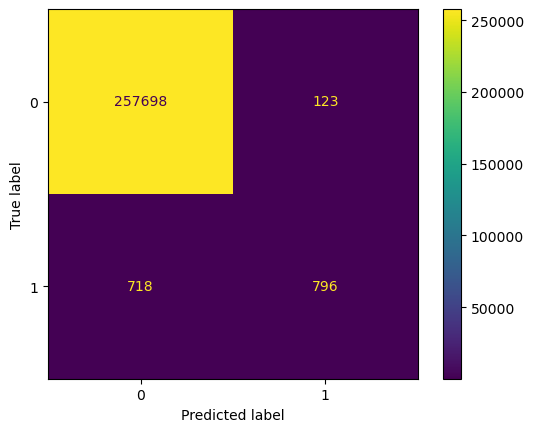

In [81]:
print('Random Forest Result')
measure_metrics(y_test_unbalanced, y_pred_rf_unbalanced)


Decision Tree Result
Accuracy: 0.9941157190506488
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257821
           1       0.50      0.53      0.51      1514

    accuracy                           0.99    259335
   macro avg       0.75      0.76      0.76    259335
weighted avg       0.99      0.99      0.99    259335

ROC AUC and curve cannot be calculated without probability scores (y_prob).


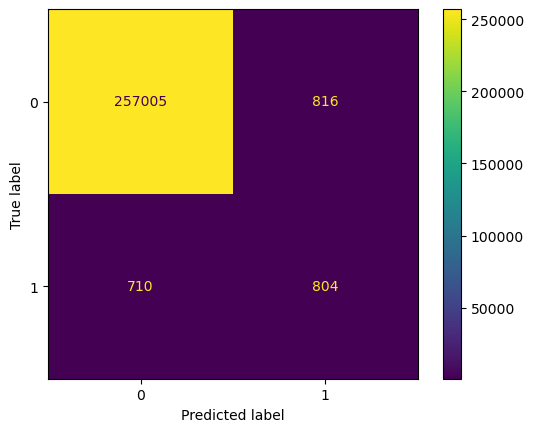

In [216]:
print('Decision Tree Result')
measure_metrics(y_test_unbalanced, y_pred_dt_unbalanced)

## SMOTE

In [85]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X_train_unbalanced, y_train_unbalanced)


balanced_df_smote = pd.concat([pd.DataFrame(X_resampled_smote, columns=X.columns), 
                               pd.DataFrame(y_resampled_smote, columns=['is_fraud'])], axis=1)

In [84]:
balanced_df_smote['is_fraud'].value_counts()

is_fraud
0    1031348
1    1031348
Name: count, dtype: int64

### DT

In [140]:
dt.fit(X_train_smote, y_train_smote)


DecisionTreeClassifier()

In [139]:
dt.feature_importances_

array([0.66030178, 0.01613093, 0.02142457, 0.03149895, 0.00879386,
       0.01556841, 0.02106254, 0.01217033, 0.01925353, 0.01314824,
       0.01560505, 0.08468343, 0.04813252, 0.01580657, 0.01641928])

In [141]:
importances = dt.feature_importances_

# Select the top n features or based on a threshold
n_features = 10  # You can also use a threshold approach
indices = np.argsort(importances)[::-1]
selected_features = indices[:n_features]

In [142]:
selected_features

array([ 0, 11, 12,  3,  6,  2,  8, 14,  1, 13])

In [143]:
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

In [144]:
feature_importance_df

,Feature,Importance
0,amt,0.660127
1,zip,0.016187
2,city_pop,0.020959
3,unix_time,0.031514
4,month,0.008718
5,day,0.015503
6,age,0.021378
7,dist_client_merch,0.011765
8,mca_category,0.019031
9,le_gender,0.013047


In [146]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

In [147]:
feature_importance_df

,Feature,Importance
4,month,0.008718
7,dist_client_merch,0.011765
9,le_gender,0.013047
5,day,0.015503
10,te_job,0.015899
13,te_city,0.016123
1,zip,0.016187
14,te_state,0.016888
8,mca_category,0.019031
2,city_pop,0.020959


In [87]:
y_pred_dt_smote = dt.predict(X_test_unbalanced)
y_prob_dt_smote = dt.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9757263770798388
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257821
           1       0.15      0.68      0.25      1514

    accuracy                           0.98    259335
   macro avg       0.57      0.83      0.62    259335
weighted avg       0.99      0.98      0.98    259335

ROC AUC Score: 0.827575827200973


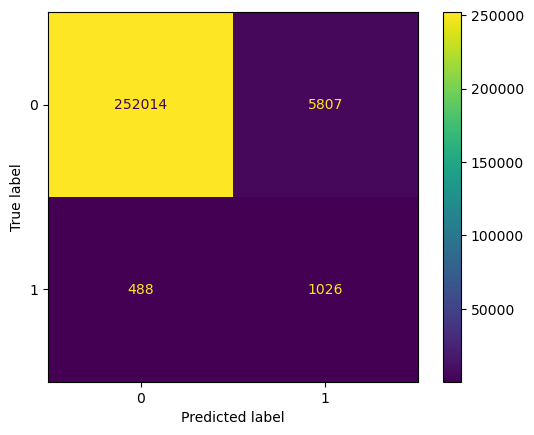

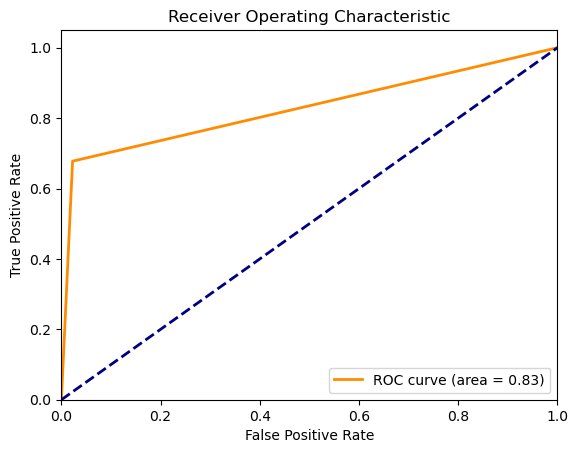

In [92]:
measure_metrics(y_test_unbalanced, y_pred_dt_smote, y_prob_dt_smote)

### RF

In [246]:
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [219]:
importances_rf = dt.feature_importances_

# Select the top n features or based on a threshold
n_features = 10  # You can also use a threshold approach
indices = np.argsort(importances)[::-1]
selected_features_rf = indices[:n_features]

In [220]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_rf
})

In [221]:
feature_importance_rf

,Feature,Importance
0,amt,0.317278
1,zip,0.026718
2,city_pop,0.036105
3,unix_time,0.054918
4,month,0.020527
5,day,0.033244
6,age,0.049557
7,dist_client_merch,0.042686
8,mca_category,0.055367
9,le_gender,0.013240


In [222]:
feature_importance_rf.sort_values(by='Importance', ascending=True)

,Feature,Importance
9,le_gender,0.013240
4,month,0.020527
1,zip,0.026718
10,te_job,0.029451
14,te_state,0.031127
5,day,0.033244
13,te_city,0.035473
2,city_pop,0.036105
7,dist_client_merch,0.042686
6,age,0.049557


In [223]:
y_pred_rf_smote = rf.predict(X_test_unbalanced)
y_prob_rf_smote = rf.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9923805116933696
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257821
           1       0.41      0.73      0.53      1514

    accuracy                           0.99    259335
   macro avg       0.71      0.86      0.76    259335
weighted avg       0.99      0.99      0.99    259335

ROC AUC Score: 0.9793386522964074


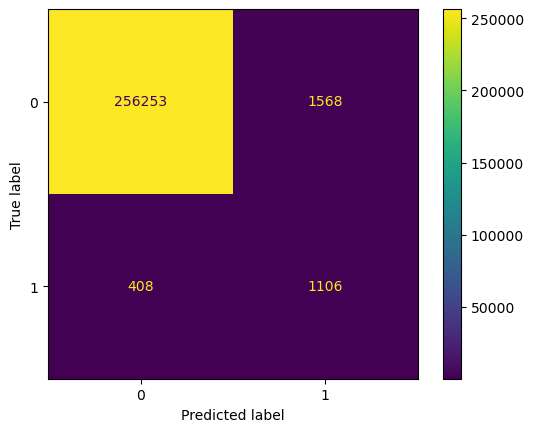

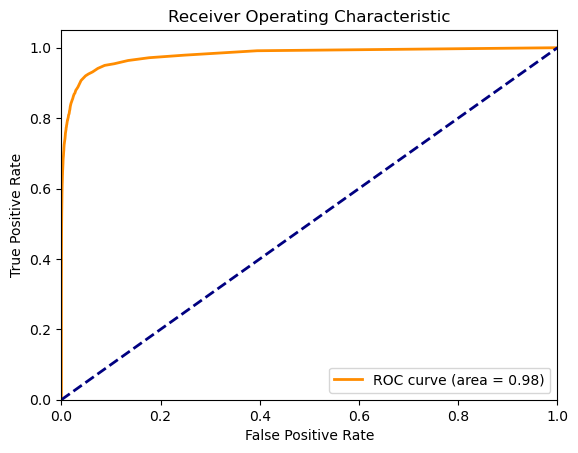

In [224]:
measure_metrics(y_test_unbalanced, y_pred_rf_smote, y_prob_rf_smote)

## SMOTE-TOMEK

In [94]:
from imblearn.combine import SMOTETomek

# Instantiate SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)

# Resample the dataset
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_unbalanced, y_train_unbalanced)

balanced_df_smote_tomek = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), 
                               pd.DataFrame(y_resampled, columns=['is_fraud'])], axis=1)

In [95]:
balanced_df_smote_tomek['is_fraud'].value_counts()

is_fraud
0    1029385
1    1029385
Name: count, dtype: int64

### DT

In [96]:
dt.fit(X_resampled, y_resampled)

DecisionTreeClassifier()

In [97]:
y_pred_dt_smote_tomek = dt.predict(X_test_unbalanced)
y_prob_dt_smote_tomek = dt.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9759153218809647
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257821
           1       0.15      0.68      0.25      1514

    accuracy                           0.98    259335
   macro avg       0.57      0.83      0.62    259335
weighted avg       0.99      0.98      0.98    259335

ROC AUC Score: 0.8279991660317388


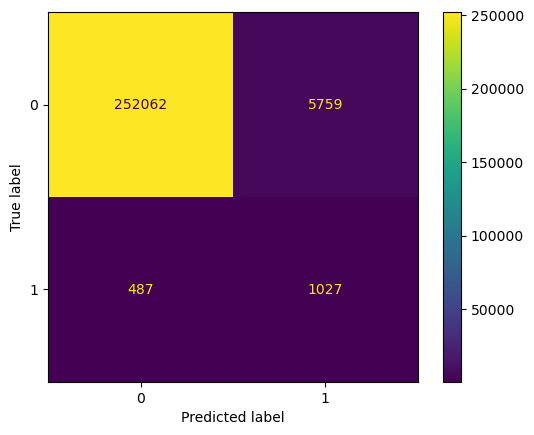

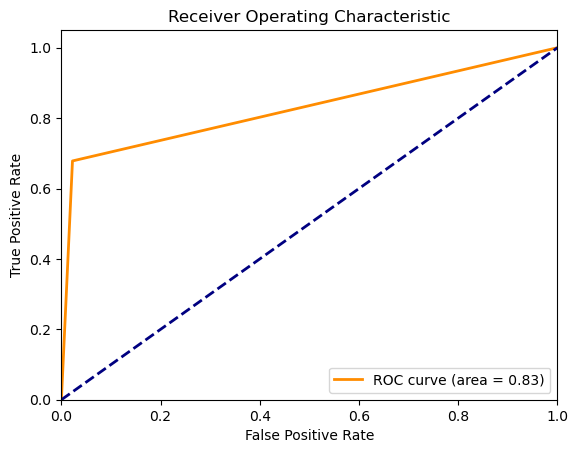

In [98]:
measure_metrics(y_test_unbalanced, y_pred_dt_smote_tomek, y_prob_dt_smote_tomek)

### RF

In [225]:
rf.fit(X_resampled, y_resampled)

RandomForestClassifier()

In [226]:
y_pred_rf_smote_tomek = rf.predict(X_test_unbalanced)
y_prob_rf_smote_tomek = rf.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9924653440530588
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257821
           1       0.42      0.73      0.53      1514

    accuracy                           0.99    259335
   macro avg       0.71      0.86      0.76    259335
weighted avg       1.00      0.99      0.99    259335

ROC AUC Score: 0.9781009383298338


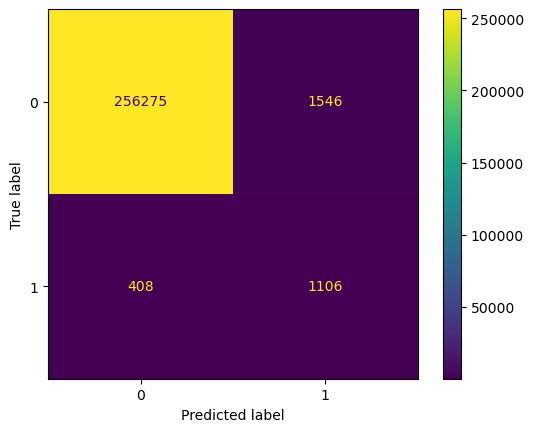

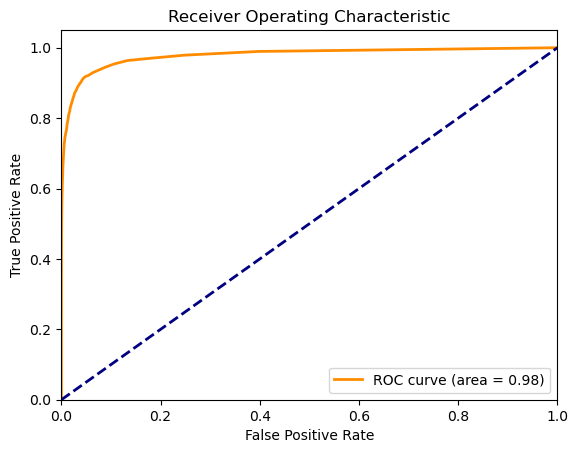

In [227]:
measure_metrics(y_test_unbalanced, y_pred_rf_smote_tomek, y_prob_rf_smote_tomek)

#### test on actual test data

In [228]:
y_pred_rf_smote_tomek_test = rf.predict(X_test_actual)
y_prob_rf_smote_tomek_test = rf.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9843230121698197
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.06      0.23      0.10      2145

    accuracy                           0.98    555719
   macro avg       0.53      0.61      0.55    555719
weighted avg       0.99      0.98      0.99    555719

ROC AUC Score: 0.9611991786570072


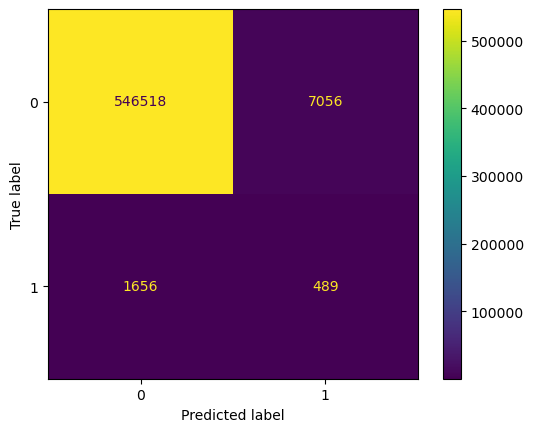

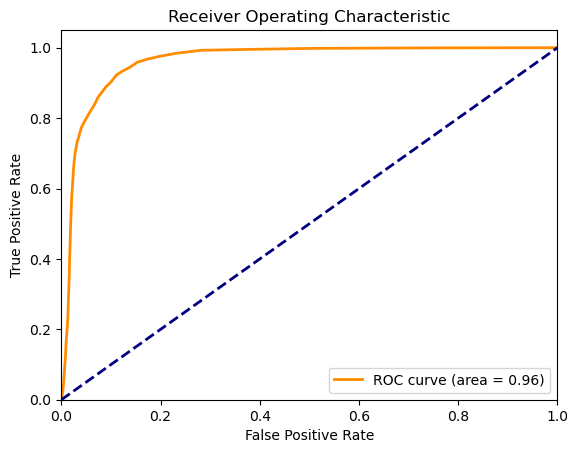

In [229]:
measure_metrics(y_test_acutal, y_pred_rf_smote_tomek_test, y_prob_rf_smote_tomek_test)

### Ensemble - Bagging (dt) - Smote_tomek

In [99]:
from sklearn.ensemble import BaggingClassifier

In [104]:
bagging_dt = BaggingClassifier(estimator=dt, n_estimators = 50, random_state=42)

#### train on balanced data (smote-tomek)

In [105]:
bagging_dt.fit(X_resampled, y_resampled)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50,
                  random_state=42)

#### Test on acutal test data

In [131]:
y_pred_bagging_dt = bagging_dt.predict(X_test_actual)
y_prob_bagging_dt = bagging_dt.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9746382614234892
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.03      0.20      0.06      2145

    accuracy                           0.97    555719
   macro avg       0.51      0.59      0.52    555719
weighted avg       0.99      0.97      0.98    555719

ROC AUC Score: 0.918132682505106


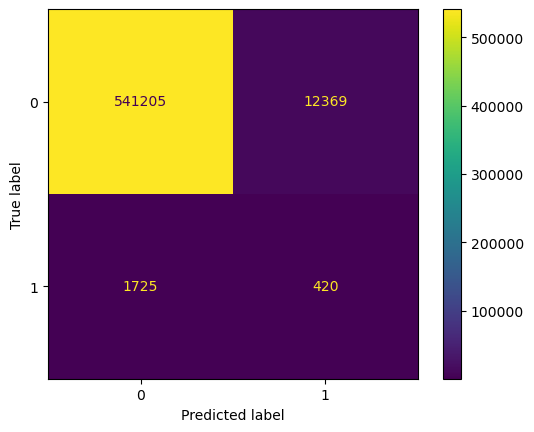

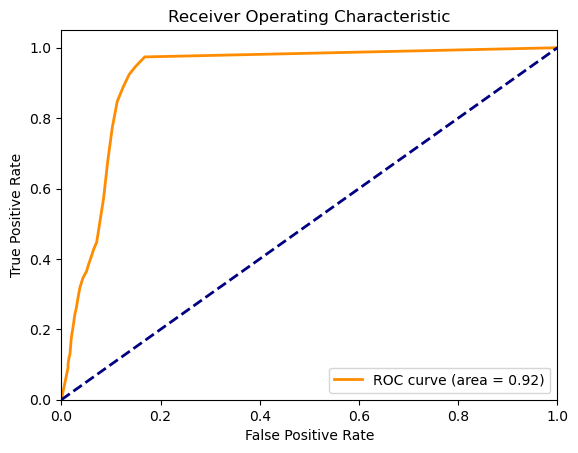

In [133]:
measure_metrics(y_test_acutal, y_pred_bagging_dt, y_prob_bagging_dt)

#### Test on unbalanced test data (from split)

In [136]:
y_pred_bagging_dt_smote_tomek = bagging_dt.predict(X_test_unbalanced)
y_prob_bagging_dt_smote_tomek = bagging_dt.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9855360826729905
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257821
           1       0.25      0.72      0.37      1514

    accuracy                           0.99    259335
   macro avg       0.62      0.85      0.68    259335
weighted avg       0.99      0.99      0.99    259335

ROC AUC Score: 0.9507623570277632


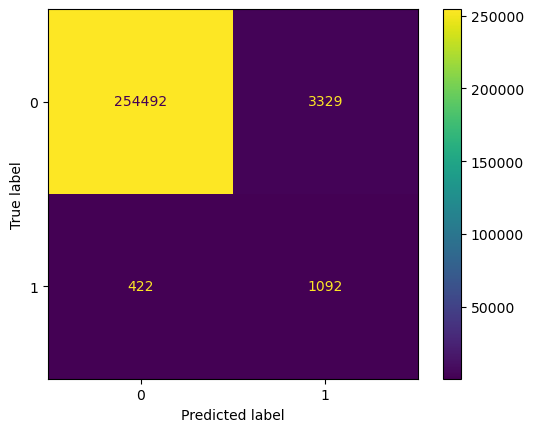

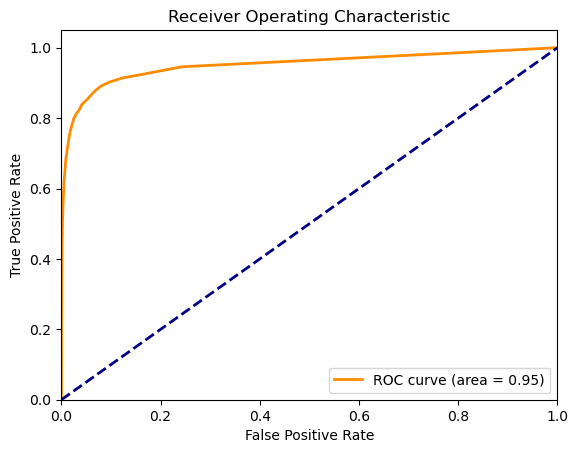

In [137]:
measure_metrics(y_test_unbalanced, y_pred_bagging_dt_smote_tomek, y_prob_bagging_dt_smote_tomek)

In [ ]:
#### Test on 

In [126]:
df_n.sample()

,amt,zip,city_pop,unix_time,is_fraud,month,day,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
507647,8.98,84532,9772,1344433887,0,8,8,34,58.583235,-0.313913,1,0.006638,0.005819,0.021228,0.005858,0.006193


In [135]:
df_test.sample()

,amt,zip,city_pop,unix_time,is_fraud,month,day,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
47836,462.98,69165,1789,1373201063,0,7,7,42,111.307048,0.155464,0,0.010614,0.00936,0.001797,0.011375,0.003741


## Feature Selection

In [148]:
# Assuming df is your DataFrame
negative_values = df_test[df_test['amt'] < 0]['amt']
count_negative_values = negative_values.count()

if count_negative_values > 0:
    print(f"Negative values in 'amt' column:\n{negative_values}")
    print(f"Count of negative values: {count_negative_values}")
else:
    print("The 'amt' column does not contain any negative values.")

The 'amt' column does not contain any negative values.


In [160]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

In [162]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
# X_test_scaled = scaler.transform(X_test)

In [163]:
selector = SelectKBest(score_func=chi2, k=10)

# Fit the selector to the training data
X_train_selected = selector.fit_transform(X_train_scaled, y)

In [168]:
selected_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_indices]

In [169]:
selected_feature_names

Index(['amt', 'unix_time', 'month', 'age', 'le_gender', 'te_job', 'te_street',
       'te_merchant', 'te_city', 'te_state'],
      dtype='object')

# Dataset 2 (after feature selection, has only 9 features) and Model 2 - Test

In [172]:
df_n.sample()

,amt,zip,city_pop,unix_time,is_fraud,month,day,age,dist_client_merch,mca_category,le_gender,te_job,te_street,te_merchant,te_city,te_state
787832,55.17,20012,601723,1354381930,0,12,1,53,104.84584,0.253783,1,0.002442,0.0,0.003452,0.005135,0.005542


In [173]:
X_2 = df_n[['amt', 'unix_time', 'month', 'age', 'le_gender', 'te_job', 'te_street','te_merchant', 'te_city']]
y_2 = df_n['is_fraud']

In [235]:
X_2_test_actual = df_test[['amt', 'unix_time', 'month', 'age', 'le_gender', 'te_job', 'te_street','te_merchant', 'te_city']]
y_2_test_actual = df_test['is_fraud']

In [230]:
# Split the dataset into training and testing sets with 30% for testing
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.3, random_state=42)

## DT

In [241]:
dt_2 = DecisionTreeClassifier()


In [242]:
dt_2.fit(X_2,y_2)

DecisionTreeClassifier()

In [243]:
y_2_pred = dt_2.predict(X_2_test)

In [244]:
y_2_prob = dt_2.predict_proba(X_2_test_actual)[:, 1]

Accuracy: 0.9904268164306061
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.19      0.45      0.27      2145

    accuracy                           0.99    555719
   macro avg       0.59      0.72      0.63    555719
weighted avg       0.99      0.99      0.99    555719

ROC AUC Score: 0.7225955695417772


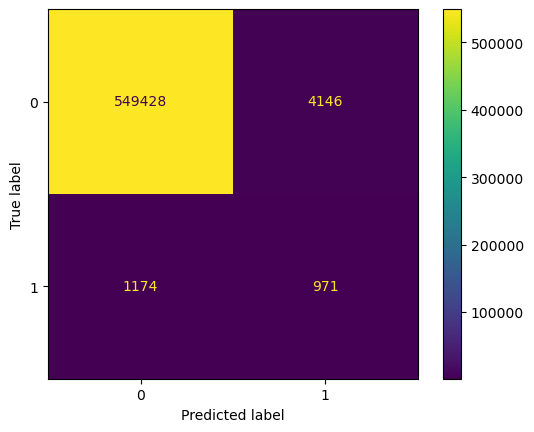

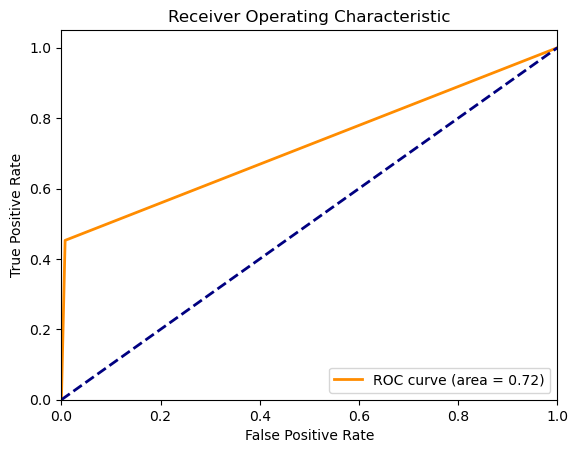

In [245]:
measure_metrics(y_2_test_actual, y_2_pred, y_2_prob)

In [258]:
df_n['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

## RF without balancing

In [247]:
rf_2 = RandomForestClassifier()

In [248]:
rf_2.fit(X_2,y_2)

RandomForestClassifier()

In [266]:
y_2_pred = rf_2.predict(X_2_test_actual)

In [267]:
y_2_prob = rf_2.predict_proba(X_2_test_actual)[:, 1]

Accuracy: 0.9973457808712677
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.80      0.42      0.55      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.71      0.77    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9708144308419971


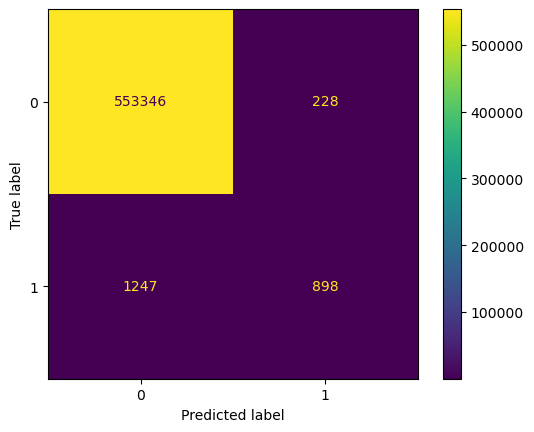

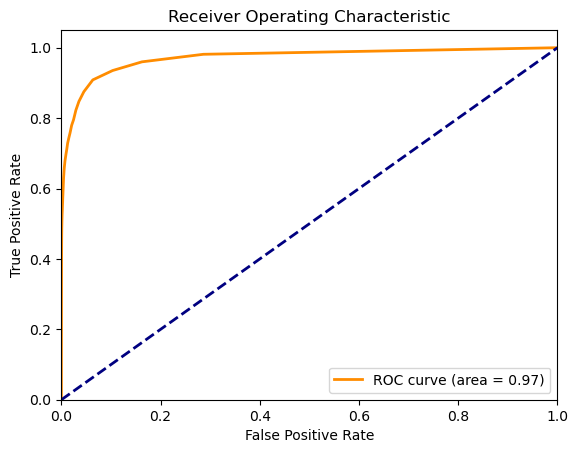

In [268]:
measure_metrics(y_2_test_actual, y_2_pred, y_2_prob)

## RF with balancing -smote

In [259]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote_2 = SMOTE(random_state=42)

# Resample the dataset
X_train_smote_2, y_train_smote_2 = smote.fit_resample(X_2, y_2)


# balanced_df_smote = pd.concat([pd.DataFrame(X_resampled_smote, columns=X.columns), 
#                                pd.DataFrame(y_resampled_smote, columns=['is_fraud'])], axis=1)

In [261]:
rf_2_smote = RandomForestClassifier()
rf_2_smote.fit(X_train_smote_2,y_train_smote_2)

RandomForestClassifier()

In [264]:
y_2_pred_smote = rf_2_smote.predict(X_2_test_actual)
y_2_prob_smote = rf_2_smote.predict_proba(X_2_test_actual)[:, 1]


Accuracy: 0.9792862939723134
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.05      0.25      0.08      2145

    accuracy                           0.98    555719
   macro avg       0.52      0.62      0.54    555719
weighted avg       0.99      0.98      0.99    555719

ROC AUC Score: 0.9508247070195427


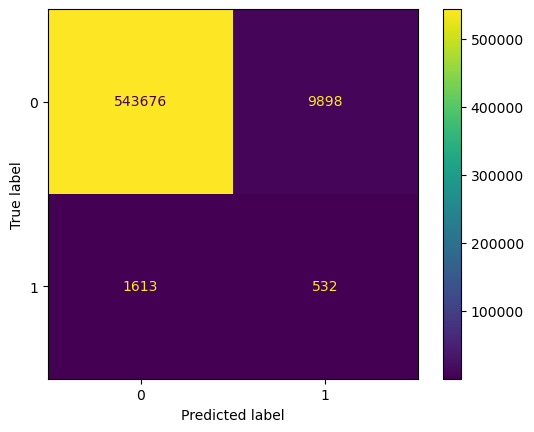

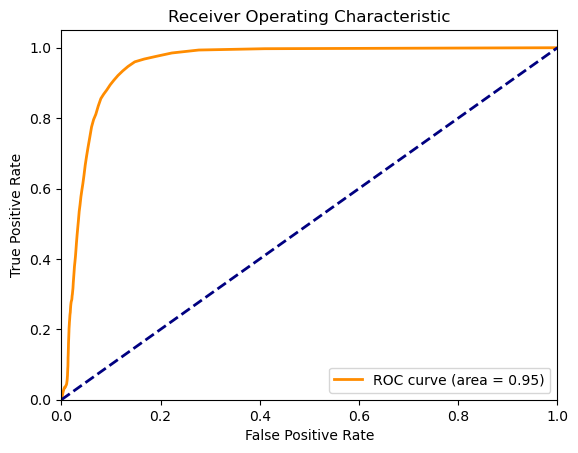

In [265]:
measure_metrics(y_2_test_actual, y_2_pred_smote, y_2_prob_smote)

## Cost Sentitive learning

In [188]:
fraud_counts = df_mod['is_fraud'].value_counts()
fraud_percentages = fraud_counts / len(df) * 100

# Print the percentages
for label, percentage in fraud_percentages.items():
    print(f"Class {label}: {percentage:.2f}%")

Class 0: 99.42%
Class 1: 0.58%


In [207]:
class_weights = {0: 0.10, 1: 0.90}

In [252]:
dt_2_csl = DecisionTreeClassifier(class_weight=class_weights)

In [253]:
dt_2_csl.fit(X_2,y_2)

DecisionTreeClassifier(class_weight={0: 0.1, 1: 0.9})

In [254]:
y_2_pred_csl = dt_2_csl.predict(X_2_test)

In [255]:
y_2_prob_csl = dt_2_csl.predict_proba(X_2_test)[:, 1]

Accuracy: 0.9935578952672124
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.21      0.23      0.22      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.62      0.61    555719
weighted avg       0.99      0.99      0.99    555719

ROC AUC Score: 0.6157311707790957


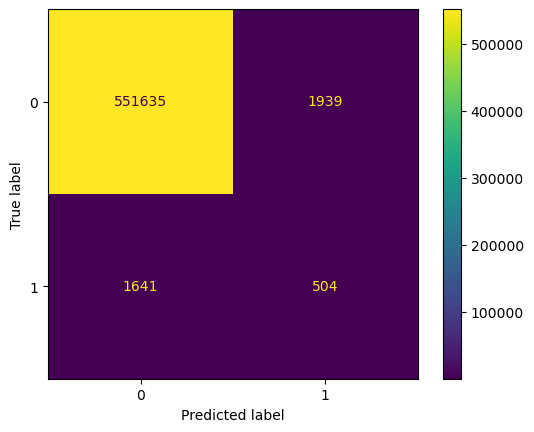

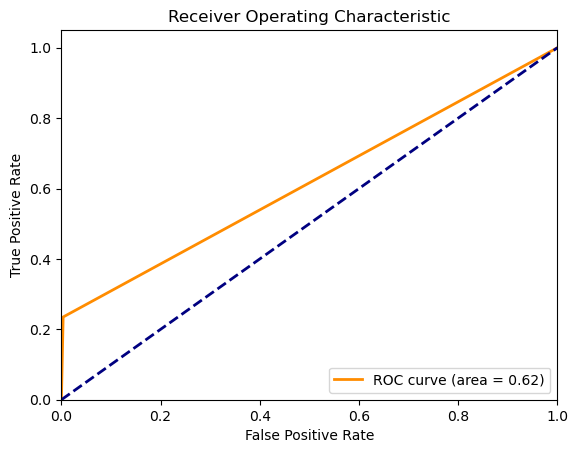

In [256]:
measure_metrics(y_2_test, y_2_pred_csl, y_2_prob_csl)

### Hyperparameter tuning for case sensitive learning

In [213]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score

# Define the parameter grid
param_grid = {
    'class_weight': [
        {0: 0.05, 1: 0.95},
        {0: 0.10, 1: 0.90},
        {0: 0.15, 1: 0.85},
        {0: 0.20, 1: 0.80},
        {0: 0.25, 1: 0.75},
        {0: 0.30, 1: 0.70},
        {0: 0.35, 1: 0.65},
        {0: 0.40, 1: 0.60},
        {0: 0.45, 1: 0.55},
        {0: 0.50, 1: 0.50}
    ]
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier()

# Define the scoring function
scoring = {
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

# Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scoring,
    refit='precision',  # You can also choose 'recall' depending on your priority
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_2, y_2)

# Get the best parameters and the best estimator
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

# Predict on the test set
y_2_pred_csl = best_rf.predict(X_2_test)
y_2_prob_csl = best_rf.predict_proba(X_2_test)[:, 1]

# Evaluate precision and recall
precision = precision_score(y_2_test, y_2_pred_csl)
recall = recall_score(y_2_test, y_2_pred_csl)

print(f"Best class weights: {best_params}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best class weights: {'class_weight': {0: 0.15, 1: 0.85}}
Precision: 0.8609271523178808
Recall: 0.18181818181818182


case sensitive learning did not work, low recall